In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import plotly.express as px
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from copy import deepcopy
import matplotlib.pyplot as plt

# Import and Carpentry of Data

In [2]:
GrdSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-C1_PGCI-GrdSrch-[27]-P3O1/raw-data_2023-04-11_Stykke4.csv")
SobSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-C3_PGCI-SobSrch-[27]-P3O1/raw-data_2023-04-11_Stykke4.csv")
RndSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-A2_PGCI-RndSrch-[27]-P3O1/raw-data_2023-03-10_PtA2-PGCI-RndSrch-[27]-P3O1_Stykke-4.csv")

RndSrch_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)

BOpt_8SP_1It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B1_PGCI-BOpt-[8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]-P3O1/raw-data_2023-03-15_PtB1-PGCI-BOpt-[8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]-P3O1-Stykke-4.csv")
BOpt_8SP_2It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B3_PGCI-BOpt-[8,2,2,2,2,2,2,2,2,2,1]-P3O1/raw-data_2023-03-20_PtB3-PGCI-BOpt-[8,2,2,2,2,2,2,2,2,2,1]-P3O1-Stykke-4.csv")
BOpt_8SP_3It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B5_PGCI-BOpt-[8,3,3,3,3,3,3,1]-P3O1/raw-data_2023-03-20_PtB5-PGCI-BOpt-[8,3,3,3,3,3,3,1]-P3O1-Stykke-4.csv")
BOpt_16SP_1It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B2_PGCI-BOpt-[16,1,1,1,1,1,1,1,1,1,1,1]-P3O1/raw-data_2023-03-11_PtB2-PGCI-BOpt-[16,1,1,1,1,1,1,1,1,1,1,1]-P3O1-Stykke-4.csv")
BOpt_16SP_2It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B4_PGCI-BOpt-[16,2,2,2,2,1]-P3O1/raw-data_2023-03-20_PtB4-PGCI-BOpt-[16,2,2,2,2,1]-P3O1-Stykke-4.csv")
BOpt_16SP_3It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B6_PGCI-BOpt-[16,3,3,3,2]-P3O1/raw-data_2023-03-20_PtB6-PGCI-BOpt-[16,3,3,3,2]-P3O1-Stykke-4.csv")

BOpt_8SP_1It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
BOpt_8SP_2It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
BOpt_8SP_3It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
BOpt_16SP_1It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
BOpt_16SP_2It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
BOpt_16SP_3It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)

ax_BOpt_8SP_1It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-D1_PGCI-BOpt-9,27,1-S2B1O1/raw-data_2023-03-15_Stykke4.csv")
ax_BOpt_8SP_2It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-D2_PGCI-BOpt-9,27,2-S2B1O1/raw-data_2023-03-15_Stykke4.csv")
ax_BOpt_8SP_3It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-D3_PGCI-BOpt-9,27,3-S2B1O1/raw-data_2023-03-15_Stykke4.csv")
ax_BOpt_16SP_1It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-D4_PGCI-BOpt-17,27,1-S2B1O1/raw-data_2023-03-11_Stykke4.csv")
ax_BOpt_16SP_2It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-D5_PGCI-BOpt-17,27,2-S2B1O1/raw-data_2023-03-11_Stykke4.csv")
ax_BOpt_16SP_3It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-D6_PGCI-BOpt-17,27,3-S2B1O1/raw-data_2023-03-11_Stykke4.csv")

In [3]:
df = pd.concat(objs=[GrdSrch_df,SobSrch_df,RndSrch_df,BOpt_8SP_1It_df,BOpt_8SP_2It_df,BOpt_8SP_3It_df,BOpt_16SP_1It_df,BOpt_16SP_2It_df,BOpt_16SP_3It_df,ax_BOpt_8SP_1It_df,ax_BOpt_8SP_2It_df,ax_BOpt_8SP_3It_df,ax_BOpt_16SP_1It_df,ax_BOpt_16SP_2It_df,ax_BOpt_16SP_3It_df])
df.drop(columns=["mould_position","G_stoichiometry","CA_stoichiometry","IA_stoichiometry","StartPolymerMass_g","EndPolymerMass_pct"],inplace=True)
df['DeltaPolymerMass_pct']=df['DeltaPolymerMass_pct']*-1
df

,s1,s2,b1,DeltaPolymerMass_pct
0,0.000000,0.000000,0.000000,14.688580
1,0.000000,0.000000,0.500000,13.023980
2,0.000000,0.000000,1.000000,11.990678
3,0.500000,0.000000,0.000000,11.688487
4,0.500000,0.000000,0.500000,12.974571
...,...,...,...,...
23,0.195706,0.141341,0.000000,15.157671
24,0.000000,0.359837,0.125651,15.739101
25,0.093065,0.000000,0.000000,14.417391
26,0.000000,0.227926,0.216711,13.718295


In [4]:
X = df[["s1","s2","b1"]].to_numpy()

In [5]:
y = df["DeltaPolymerMass_pct"].to_numpy()

# Bayesian Optimisation Tuning of Hyperparameters

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

tree_methods = ['approx', 'exact', 'hist']

space = {
    'tree_method': hp.choice('tree_method', tree_methods),
    'max_depth': hp.randint('max_depth', 3, 12),
    'num_parallel_tree': hp.randint('num_parallel_tree', 2, 8),
    'min_child_weight': hp.randint('min_child_weight', 1, 200),
    'subsample': hp.uniform('subsample', 0.7, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
    'colsample_bylevel': hp.uniform('colsample_bylevel', 0.5, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 10),
    'learning_rate': hp.uniform('learning_rate', 0, 1),
}

def objective(params):
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, y_pred))
    return {'loss': RMSLE, 'status': STATUS_OK}

trials = Trials()

best_params = fmin(objective, space, algo=tpe.suggest, max_evals=100, trials=trials)
best_params["tree_method"] = tree_methods[best_params["tree_method"]]
print("Best set of hyperparameters: ", best_params)

100%|██████████| 100/100 [00:23<00:00,  4.27trial/s, best loss: 0.0789066874752421]
Best set of hyperparameters:  {'colsample_bylevel': 0.5015058768535854, 'colsample_bytree': 0.7735683004922266, 'learning_rate': 0.5500706426207792, 'max_depth': 9, 'min_child_weight': 3, 'num_parallel_tree': 5, 'reg_lambda': 5.710203025043431, 'subsample': 0.7459611833804767, 'tree_method': 'exact'}


In [7]:
dtrain = xgb.DMatrix(data=X_train,label=y_train,enable_categorical=True)
dvalid = xgb.DMatrix(data=X_test,label=y_test,enable_categorical=True)
num_boost_round = 500
evals_result = {}
xgb_model = xgb.train(params=best_params, dtrain=dtrain, num_boost_round=num_boost_round,evals=[(dtrain, 'train'), (dvalid, 'valid')],verbose_eval=10,evals_result=evals_result,early_stopping_rounds=10)

[0]	train-rmse:1.30230	valid-rmse:1.26665
[10]	train-rmse:0.52997	valid-rmse:1.02800
[16]	train-rmse:0.39843	valid-rmse:1.03725


Text(0, 0.5, 'objective')

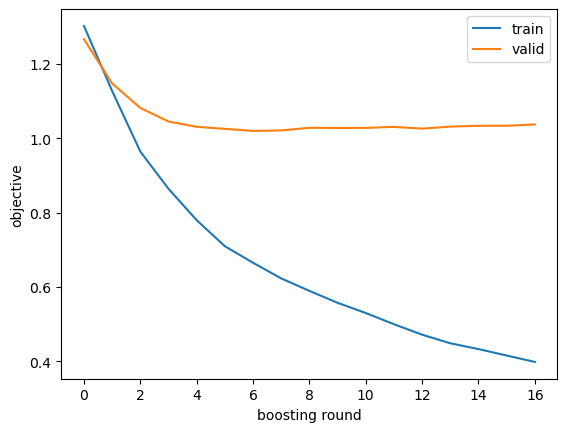

In [9]:
pd.DataFrame({
    'train': evals_result['train']['rmse'],
    'valid': evals_result['valid']['rmse']
}).plot(); plt.xlabel('boosting round'); plt.ylabel('objective')

In [10]:
# xgb_model = xgb.XGBRegressor()
# xgb_model.load_model('/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/Modelling/ModelMk1.json')
n = 11
iCoords_arr = np.linspace(0,1,n-1)
jCoords_arr = np.linspace(0,1,n-1)
kCoords_arr = np.linspace(0,1,n-1)
ijkCoords_lis = []
for i in iCoords_arr:
    for j in jCoords_arr:
        for k in kCoords_arr:
            ijkCoords_lis.append([i,j,k])
ijkCoords_arr = np.array(ijkCoords_lis)
ijkCoords_dmat = xgb.DMatrix(ijkCoords_arr)
y_pred = xgb_model.predict(ijkCoords_dmat)
df2 = pd.DataFrame({'s1': ijkCoords_arr[:, 0],'s2': ijkCoords_arr[:, 1],'b1': ijkCoords_arr[:, 2], 'y_pred': y_pred})
df2["y_pred"] = y_pred
fig = px.scatter_3d(df2, x='s1', y='s2', z='b1', color='y_pred')
fig.show()

In [11]:
n = 200
iCoords_arr = np.linspace(0,1,n-1)
jCoords_arr = np.linspace(0,1,n-1)
kCoords_arr = np.linspace(0,1,n-1)
ijkCoords_lis = []
for i in iCoords_arr:
    for j in jCoords_arr:
        for k in kCoords_arr:
            ijkCoords_lis.append([i,j,k])
ijkCoords_arr = np.array(ijkCoords_lis)
ijkCoords_dmat = xgb.DMatrix(ijkCoords_arr)
y_pred = xgb_model.predict(ijkCoords_dmat)
print(np.max(y_pred))
print(ijkCoords_arr[np.argmax(y_pred)])

17.729216
[0.33838384 0.65656566 0.77272727]


In [12]:
xgb_model.save_model('ModelMk3.json')

In [13]:
from types import resolve_bases
import pickle

d = {"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "best_params": best_params, "num_boost_round": len(evals_result["valid"]["rmse"])}

with open('ModelMk3.pkl', 'wb') as file:
    pickle.dump(d, file)